In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.load_data import get_validated_data

In [3]:
# Load the validated data
data = get_validated_data()
data.head(5)

,appid,name,release_year,release_date,genres,categories,price,recommendations,developer,publisher
0,3057270,Seafarer's Gambit,2024,2024-07-05,Action;Adventure;Indie;RPG;Strategy,Single-player;Family Sharing,3.99,0,Bouncy Rocket Studios,Bouncy Rocket Studios
1,3822840,Capitalist Misadventures,2025,2025-07-25,Casual;Indie;Simulation;Strategy,Single-player;Save Anytime;Family Sharing,7.99,0,Caramelo Studios,Caramelo Studios
2,3216640,The Beast and the Princess,2025,2025-06-17,Adventure;Indie;Strategy,Single-player;Steam Achievements;Full controll...,12.99,0,Libragames,Libragames
3,2403620,Air Twister,2023,2023-11-10,Action;Adventure;Indie,Single-player;Steam Achievements;Full controll...,24.99,0,YS Net,ININ
4,1538040,Horde Slayer,2021,2021-03-19,Action;Adventure;Casual;Indie;RPG;Early Access,Single-player;Steam Achievements;Full controll...,3.99,0,Wagner Rodrigues,Wagner Rodrigues


## General analysis
Find problems that need to be fixed before train models

In [4]:
# General information
data.info()
print(f'\nDescription: \n{data.describe()}')

<class 'pandas.DataFrame'>
RangeIndex: 63995 entries, 0 to 63994
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   appid            63995 non-null  int64         
 1   name             63995 non-null  str           
 2   release_year     63995 non-null  int64         
 3   release_date     63995 non-null  datetime64[us]
 4   genres           63995 non-null  str           
 5   categories       63995 non-null  str           
 6   price            63995 non-null  float64       
 7   recommendations  63995 non-null  int64         
 8   developer        63995 non-null  str           
 9   publisher        63995 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(3), str(5)
memory usage: 13.2 MB

Description: 
              appid  release_year                release_date         price  \
count  6.399500e+04  63995.000000                       63995  63995.000000   
mean   2.564644

In [5]:
# Release date analysis
release_years_count = data['release_year'].value_counts()
popular_release_dates = data['release_date'].value_counts()
popular_release_dates_50 = popular_release_dates[popular_release_dates > 50].shape[0]
print(f'Release years count: {release_years_count}')
print(f'Number of days where a game was released: {popular_release_dates.shape[0]}')
print(f'Number of days where more than 50 games were released: {popular_release_dates_50}')
print(f'Release mean: {popular_release_dates.mean()}')
print(f'Release mode: {popular_release_dates.mode()[0]}')
print(f'Release median: {popular_release_dates.median()}')
print(f'Release max: {popular_release_dates.max()}')
print(f'Release min: {popular_release_dates.min()}')

Release years count: release_year
2025    18693
2024    15817
2023    11525
2022     9594
2021     8366
Name: count, dtype: int64
Number of days where a game was released: 1825
Number of days where more than 50 games were released: 393
Release mean: 35.06575342465754
Release mode: 17
Release median: 31.0
Release max: 150
Release min: 1


In [6]:
# Popular genres
splitted_genres = data['genres'].str.split(';')
popular_genres_combination = splitted_genres.value_counts()
genres_count = splitted_genres.explode().value_counts()
number_of_less_popular_genres_combination = len(popular_genres_combination) - 20
print(f'Popular genres combination: {popular_genres_combination.head(15)}')
print(f'\nGenres count: {genres_count.head(20)}')
print(f'\nNumber of less popular genres combination: {number_of_less_popular_genres_combination}')

Popular genres combination: genres
[Casual, Indie]                       4079
[Action, Adventure, Indie]            2801
[Action, Indie]                       2563
[Adventure, Indie]                    2258
[Casual]                              2166
[Adventure, Casual, Indie]            2021
[Action, Casual, Indie]               1676
[Indie]                               1638
[Action]                              1589
[Casual, Indie, Simulation]           1416
[Casual, Indie, Strategy]             1388
[Adventure]                           1216
[Action, Adventure, Casual, Indie]    1131
[Action, Adventure]                    962
[Action, Adventure, Indie, RPG]        781
Name: count, dtype: int64

Genres count: genres
Indie                    45021
Casual                   30150
Adventure                25929
Action                   25123
Simulation               14136
Strategy                 12683
RPG                      12325
Free To Play              7892
Early Access            

In [7]:
# Popular categories
splitted_categories = data['categories'].str.split(';')
popular_categories_combination = splitted_categories.value_counts()
categories_count = splitted_categories.explode().value_counts()
print(f'Popular categories combination: {popular_categories_combination.head(10)}')
print(f'\nCategories count: {categories_count.head(20)}')
number_of_less_popular_categories_combination = len(popular_categories_combination) - 20
print(f'\nNumber of less popular categories combination: {number_of_less_popular_categories_combination}')

Popular categories combination: categories
[Single-player, Family Sharing]                                                              14727
[Single-player, Steam Achievements, Family Sharing]                                           6154
[Single-player]                                                                               3138
[Single-player, Steam Achievements, Steam Cloud, Family Sharing]                              2774
[Single-player, Steam Achievements, Full controller support, Steam Cloud, Family Sharing]     2261
[Single-player, Steam Achievements, Full controller support, Family Sharing]                  2000
[Single-player, Full controller support, Family Sharing]                                      1966
[Single-player, Partial Controller Support, Family Sharing]                                   1447
[Single-player, Steam Cloud, Family Sharing]                                                  1076
[Single-player, Steam Achievements, Partial Controller Support, Fa

In [8]:
# recommendations
recommendations_count = data['recommendations'].value_counts()
print(f'Recommendations count equal to 0: {recommendations_count.head(1).values[0]}')
print(f'Recommendations count equal to 1: {recommendations_count[recommendations_count == 1].shape[0]}')
print(f'Recommendations mode: {recommendations_count.mode()[0]}')
print(f'Recommendations median: {recommendations_count.median()}')
print(f'Recommendations higher than 10: {recommendations_count[recommendations_count > 10].shape[0]}')

Recommendations count equal to 0: 56045
Recommendations count equal to 1: 1555
Recommendations mode: 1
Recommendations median: 1.0
Recommendations higher than 10: 161


In [9]:
# developer and publisher
developer_is_developer = data['developer'] == data['publisher']
developer_count = data['developer'].value_counts().head(10)
publisher_count = data['publisher'].value_counts().head(10)
print(f'Number of games where developer is publisher: {developer_is_developer.sum()}')
display(f'\nTop 10 developers: {developer_count}')
display(f'\nTop 10 publishers: {publisher_count}')

Number of games where developer is publisher: 46975


"\nTop 10 developers: developer\nEroticGamesClub          215\nBully Revenge Studios    119\nGamesforgames             96\nDo Games Limited          90\nArchor Wright             88\nKing Kong                 87\nCyber Keks                85\nBoogygames Studios        83\nCute Hannah's Games       72\nFollow the fun            72\nName: count, dtype: int64"

'\nTop 10 publishers: publisher\nEroticGamesClub                    215\nUnknown                            173\nBFG Entertainment                  172\n8floor                             150\nHede                               142\nBully Revenge Studios              119\nKagura Games                       119\nDigiPen Institute of Technology    100\nGamesforgames                       98\nindie.io                            95\nName: count, dtype: int64'

## Visualization of the general analysis findings

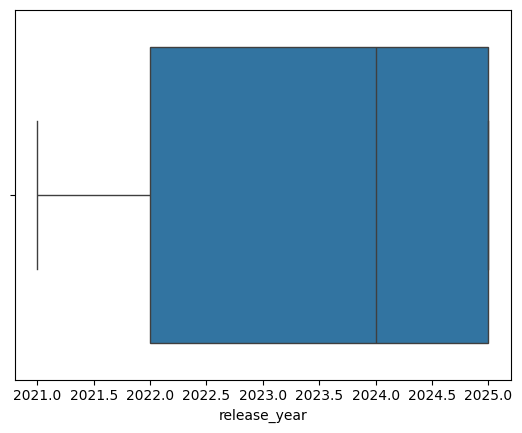

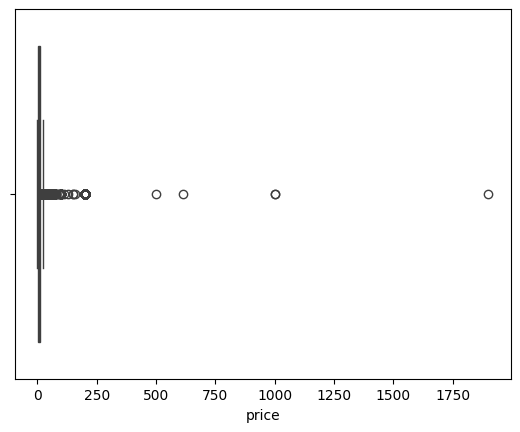

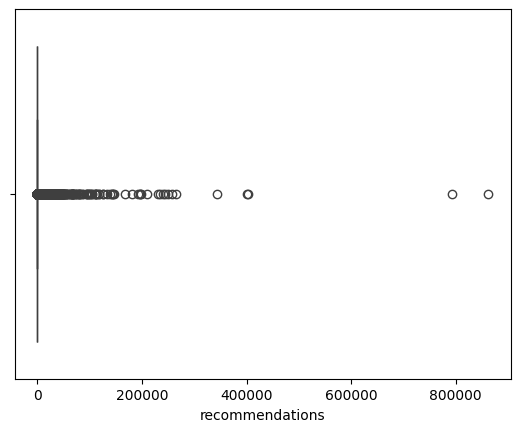

In [10]:
sns.boxplot(x=data['release_year'])
plt.show()

sns.boxplot(x=data['price'])
plt.show()

sns.boxplot(x=data['recommendations'])
plt.show()


## Data Preprocessing 

## Advanced Exploratory Data Analysis

In [ ]:
# One hot encoding for genres and categories
data.corr(numeric_only=True) 

,appid,release_year,price,recommendations
appid,1.000000,0.822193,-0.049377,-0.037159
release_year,0.822193,1.000000,0.013420,-0.008288
price,-0.049377,0.013420,1.000000,0.060516
recommendations,-0.037159,-0.008288,0.060516,1.000000
